## Step# 01 : Environment Setup

In [1]:
# Import numpy library and give it a short name "np".
# numpy is used for numerical work, arrays, random numbers, and mathematical operations.
import numpy as np

# Import pandas library and give it a short name "pd".
# pandas is used to create and manage tabular data like rows and columns.
import pandas as pd

# Import matplotlib's pyplot module and give it a short name "plt".
# matplotlib is used to draw graphs, charts, and visualizations.
import matplotlib.pyplot as plt

# Import seaborn library and give it a short name "sns".
# seaborn is used to make statistical graphs like heatmaps and count plots.
import seaborn as sns

# Import train_test_split from sklearn.model_selection.
# train_test_split is used to divide the dataset into training data and testing data.
# Training data is used to teach the model.
# Testing data is used to check how well the model performs on unseen data.
from sklearn.model_selection import train_test_split

# Import StandardScaler from sklearn.preprocessing.
# StandardScaler is used to normalize numerical features.
# It converts values into a common scale so that large values like weight do not dominate small values like voltage.
from sklearn.preprocessing import StandardScaler

# Import LabelEncoder from sklearn.preprocessing.
# LabelEncoder is used to convert text labels into numbers.
# Example: "metal_can" may become 0, "plastic_bottle" may become 1.
from sklearn.preprocessing import LabelEncoder

# Import KNeighborsClassifier from sklearn.neighbors.
# KNeighborsClassifier is the KNN model.
# KNN classifies a new object by looking at the nearest existing objects in the dataset.
from sklearn.neighbors import KNeighborsClassifier

# Import GaussianNB from sklearn.naive_bayes.
# GaussianNB is the Naive Bayes model for continuous numerical data.
# It works well when features are numeric sensor readings.
from sklearn.naive_bayes import GaussianNB

# Import accuracy_score from sklearn.metrics.
# accuracy_score tells how many predictions are correct out of total predictions.
from sklearn.metrics import accuracy_score

# Import confusion_matrix from sklearn.metrics.
# confusion_matrix shows correct and wrong predictions class by class.
from sklearn.metrics import confusion_matrix

# Import classification_report from sklearn.metrics.
# classification_report gives precision, recall, F1-score, and support for each class.
from sklearn.metrics import classification_report

# Set random seed to 42.
# This makes random results repeatable.
# It means whenever we run the notebook again, we get the same synthetic dataset and same results.
np.random.seed(42)

# Set seaborn graph style to "whitegrid".
# This makes graphs cleaner and easier to read in the report.
sns.set_style("whitegrid")

# Print a confirmation message.
# This helps us check that all required libraries are imported successfully.
print("Environment setup completed successfully!")

# Print numpy version.
# This is useful for documentation and checking library setup.
print("NumPy version:", np.__version__)

# Print pandas version.
# This is useful because pandas will handle our dataset table.
print("Pandas version:", pd.__version__)

Environment setup completed successfully!
NumPy version: 2.0.2
Pandas version: 2.2.2


## Step 2: Synthetic Dataset Creation

In [2]:
# Import numpy as np for numerical operations and generating random data
# We'll use np.random to generate synthetic values for the dataset
import numpy as np

# Set the number of samples (rows) we want to generate for the synthetic dataset
num_samples = 500  # We want 500 samples in the dataset

# Create synthetic features for the dataset

# Distance readings (in cm) between 10 and 100 (e.g., distance from sensor to object)
# np.random.uniform generates random numbers uniformly distributed within a specified range.
distance = np.random.uniform(10, 100, num_samples)  # Random float values between 10 and 100

# Size of the object in cm (e.g., radius or dimension of the object)
# Again, using np.random.uniform to simulate varying object sizes.
size = np.random.uniform(5, 50, num_samples)  # Random float values between 5 and 50

# Color intensity (on a scale from 0 to 255, typical for image data)
# np.random.randint generates random integers between the specified range.
color_intensity = np.random.randint(0, 256, num_samples)  # Random integer values between 0 and 255

# Weight of the object in grams (e.g., based on object material)
# Using np.random.uniform to simulate weight.
weight = np.random.uniform(50, 500, num_samples)  # Random float values between 50 and 500

# Sensor voltage readings (in Volts) ranging from 0.5V to 5V
# np.random.uniform is again used to simulate voltage variations.
sensor_voltage = np.random.uniform(0.5, 5, num_samples)  # Random float values between 0.5 and 5

# Now, we need to create the target labels (classes)
# Let's assume we have 4 different object classes: 'metal_can', 'plastic_bottle', 'wooden_block', 'rubber_ball'
# np.random.choice selects a random element from a list (our object classes) for each sample.
object_classes = ['metal_can', 'plastic_bottle', 'wooden_block', 'rubber_ball']
labels = np.random.choice(object_classes, num_samples)  # Randomly assign a label from the list to each sample

# Now, we'll combine the features into a single dataset (table) using pandas DataFrame
import pandas as pd

# Create a pandas DataFrame using the generated features and labels
data = pd.DataFrame({
    'distance': distance,  # Distance feature (cm)
    'size': size,  # Object size feature (cm)
    'color_intensity': color_intensity,  # Color intensity feature (0-255)
    'weight': weight,  # Weight feature (grams)
    'sensor_voltage': sensor_voltage,  # Sensor voltage feature (Volts)
    'label': labels  # Target labels (object classes)
})

# Print the first few rows of the dataset to inspect
print("Synthetic Dataset Preview:")
print(data.head())  # Displays the first 5 rows of the synthetic dataset

# Save the dataset as a CSV file for later use
data.to_csv('synthetic_robotic_dataset.csv', index=False)

# Confirm the dataset has been created
print("\nSynthetic dataset created and saved as 'synthetic_robotic_dataset.csv'")

Synthetic Dataset Preview:
    distance       size  color_intensity      weight  sensor_voltage  \
0  43.708611  36.417277               46  408.441781        2.908896   
1  95.564288  29.124336               11  266.685058        1.468408   
2  75.879455  18.928743               61  102.788685        0.554543   
3  63.879264  41.620776               79  106.333606        1.585407   
4  24.041678  35.812903              215  358.504379        4.891432   

         label  
0    metal_can  
1    metal_can  
2    metal_can  
3    metal_can  
4  rubber_ball  

Synthetic dataset created and saved as 'synthetic_robotic_dataset.csv'


## Step 3: Data Preprocessing

In [3]:
# Import necessary libraries for preprocessing
from sklearn.model_selection import train_test_split  # For splitting dataset into train and test sets
from sklearn.preprocessing import StandardScaler  # For normalizing the numerical features
from sklearn.preprocessing import LabelEncoder  # For encoding categorical labels (object classes)

# Load the synthetic dataset from the saved CSV file
# pd.read_csv reads the dataset from the file and returns it as a pandas DataFrame
data = pd.read_csv('synthetic_robotic_dataset.csv')

# Check for missing values (NaN) in the dataset
# data.isnull().sum() will return the number of missing values in each column.
print("Missing values in each column:")
print(data.isnull().sum())

# Normalize the numerical features (distance, size, color_intensity, weight, sensor_voltage)
# StandardScaler standardizes features by removing the mean and scaling to unit variance.
# This is useful because some algorithms like KNN are sensitive to the scale of the features.
scaler = StandardScaler()  # Initialize the StandardScaler
data[['distance', 'size', 'color_intensity', 'weight', 'sensor_voltage']] = scaler.fit_transform(data[['distance', 'size', 'color_intensity', 'weight', 'sensor_voltage']])
# .fit_transform() normalizes the specified columns by computing the mean and standard deviation,
# then applies the transformation to those columns.

# Encode the categorical labels into numerical values (metal_can, plastic_bottle, etc.)
# LabelEncoder transforms the string labels into integer labels.
label_encoder = LabelEncoder()  # Initialize the LabelEncoder
data['label'] = label_encoder.fit_transform(data['label'])  # Fit and transform the 'label' column into numeric values

# Print the first few rows of the dataset after preprocessing
print("\nPreprocessed Dataset Preview:")
print(data.head())  # Displays the first 5 rows of the preprocessed dataset

# Split the dataset into features (X) and labels (y)
# X will be all columns except the 'label' column (input features).
# y will be the 'label' column (target labels).
X = data.drop('label', axis=1)  # Drop 'label' column from X
y = data['label']  # Select 'label' column as y

# Split the dataset into training and testing sets (80% for training, 20% for testing)
# train_test_split randomly splits the data into training and testing sets.
# We set random_state for reproducibility, ensuring the split is the same each time.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shape of the training and testing datasets
# This will give us the number of samples and features in both the training and testing sets.
print("\nTraining and Testing Set Shapes:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Missing values in each column:
distance           0
size               0
color_intensity    0
weight             0
sensor_voltage     0
label              0
dtype: int64

Preprocessed Dataset Preview:
   distance      size  color_intensity    weight  sensor_voltage  label
0 -0.415636  0.758080        -1.058187  1.051118        0.095172      0
1  1.515310  0.189844        -1.521144 -0.038784       -1.012108      0
2  0.782307 -0.604555        -0.859777 -1.298908       -1.714582      0
3  0.335457  1.163515        -0.621685 -1.271652       -0.922173      0
4 -1.147973  0.710990         1.177233  0.667173        1.619116      2

Training and Testing Set Shapes:
X_train shape: (400, 5)
X_test shape: (100, 5)


## Step 4: Improve the Dataset — realistic synthetic robotic dataset

In [4]:
# Import numpy library and give it short name "np".
# numpy is used to generate numerical synthetic sensor readings for the robot.
import numpy as np

# Import pandas library and give it short name "pd".
# pandas is used to store the generated dataset in table form using DataFrame.
import pandas as pd

# Set random seed to 42.
# This makes the random values repeatable, so every time we run the code, same type of dataset is created.
np.random.seed(42)

# Set number of samples for each object class.
# Here each class will have 125 samples.
# Total samples will become 125 * 4 = 500.
samples_per_class = 125

# Create an empty list named "data".
# We will store all generated rows inside this list.
data = []

# Create synthetic data for metal_can class.
# Metal cans are usually heavier than plastic bottles and may give stronger sensor voltage.
for i in range(samples_per_class):

    # Generate distance value for metal can between 15 cm and 90 cm.
    # np.random.uniform(15, 90) gives one random decimal value between 15 and 90.
    distance = np.random.uniform(15, 90)

    # Generate size value for metal can between 8 cm and 20 cm.
    # Metal cans are usually small or medium in size.
    size = np.random.uniform(8, 20)

    # Generate color intensity between 120 and 220.
    # Metal surface can reflect more light, so intensity is kept higher.
    color_intensity = np.random.randint(120, 221)

    # Generate weight value between 250 g and 500 g.
    # Metal cans are usually heavier than plastic bottles.
    weight = np.random.uniform(250, 500)

    # Generate sensor voltage between 3.0 V and 5.0 V.
    # Metal objects may produce stronger sensor response.
    sensor_voltage = np.random.uniform(3.0, 5.0)

    # Add one complete row into the data list.
    # Each row contains five input features and one output label.
    data.append([distance, size, color_intensity, weight, sensor_voltage, "metal_can"])

# Create synthetic data for plastic_bottle class.
# Plastic bottles are usually light and medium in size.
for i in range(samples_per_class):

    # Generate distance value for plastic bottle between 15 cm and 90 cm.
    # Distance is not strongly class-specific, so same general range is used.
    distance = np.random.uniform(15, 90)

    # Generate size value for plastic bottle between 18 cm and 40 cm.
    # Plastic bottles are usually taller/larger than cans.
    size = np.random.uniform(18, 40)

    # Generate color intensity between 60 and 180.
    # Plastic can have medium color intensity depending on material.
    color_intensity = np.random.randint(60, 181)

    # Generate weight value between 30 g and 150 g.
    # Plastic bottles are normally light.
    weight = np.random.uniform(30, 150)

    # Generate sensor voltage between 0.5 V and 2.0 V.
    # Plastic gives weaker sensor response than metal.
    sensor_voltage = np.random.uniform(0.5, 2.0)

    # Add one complete plastic_bottle row into the data list.
    data.append([distance, size, color_intensity, weight, sensor_voltage, "plastic_bottle"])

# Create synthetic data for wooden_block class.
# Wooden blocks usually have medium weight and medium sensor response.
for i in range(samples_per_class):

    # Generate distance value for wooden block between 15 cm and 90 cm.
    # Same distance range is used because robot may detect objects at different distances.
    distance = np.random.uniform(15, 90)

    # Generate size value for wooden block between 10 cm and 30 cm.
    # Wooden blocks are usually medium-sized.
    size = np.random.uniform(10, 30)

    # Generate color intensity between 40 and 130.
    # Wood usually has lower to medium color intensity.
    color_intensity = np.random.randint(40, 131)

    # Generate weight value between 150 g and 320 g.
    # Wood is heavier than plastic but lighter than many metal objects.
    weight = np.random.uniform(150, 320)

    # Generate sensor voltage between 1.5 V and 3.2 V.
    # Wooden object gives medium sensor response.
    sensor_voltage = np.random.uniform(1.5, 3.2)

    # Add one complete wooden_block row into the data list.
    data.append([distance, size, color_intensity, weight, sensor_voltage, "wooden_block"])

# Create synthetic data for rubber_ball class.
# Rubber balls are usually round, small/medium, and not very heavy.
for i in range(samples_per_class):

    # Generate distance value for rubber ball between 15 cm and 90 cm.
    # Distance range is same because robot can observe the ball from different positions.
    distance = np.random.uniform(15, 90)

    # Generate size value for rubber ball between 6 cm and 18 cm.
    # Rubber balls are usually smaller than bottles and wooden blocks.
    size = np.random.uniform(6, 18)

    # Generate color intensity between 150 and 255.
    # Rubber balls are often colorful, so intensity is kept high.
    color_intensity = np.random.randint(150, 256)

    # Generate weight value between 80 g and 220 g.
    # Rubber ball weight is usually light to medium.
    weight = np.random.uniform(80, 220)

    # Generate sensor voltage between 1.0 V and 2.8 V.
    # Rubber gives low to medium sensor response.
    sensor_voltage = np.random.uniform(1.0, 2.8)

    # Add one complete rubber_ball row into the data list.
    data.append([distance, size, color_intensity, weight, sensor_voltage, "rubber_ball"])

# Create column names for the dataset.
# These names describe each sensor reading and the output class.
columns = ["distance", "size", "color_intensity", "weight", "sensor_voltage", "label"]

# Convert the data list into a pandas DataFrame.
# DataFrame means a table with rows and columns.
df = pd.DataFrame(data, columns=columns)

# Shuffle the dataset rows randomly.
# frac=1 means use 100% of the rows while shuffling.
# random_state=42 keeps the shuffle result same every time.
# reset_index(drop=True) removes the old row numbers and creates new clean row numbers.
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the improved dataset into a CSV file.
# index=False means do not save extra row index column in the CSV file.
df.to_csv("synthetic_robotic_dataset.csv", index=False)

# Print first 5 rows of the improved dataset.
# This helps us quickly check whether dataset is created correctly.
print("Improved Synthetic Robotic Dataset Preview:")

# df.head() shows first 5 rows of the dataset.
print(df.head())

# Print total number of rows and columns.
# df.shape returns output in the form: (number_of_rows, number_of_columns).
print("\nDataset shape:", df.shape)

# Print how many samples are present in each class.
# value_counts() counts total rows for each object class.
print("\nClass distribution:")

# This shows whether all classes have equal number of samples or not.
print(df["label"].value_counts())

# Print confirmation message after saving the dataset.
# This tells us the improved dataset has replaced the old CSV file.
print("\nImproved dataset created and saved as 'synthetic_robotic_dataset.csv'")

Improved Synthetic Robotic Dataset Preview:
    distance       size  color_intensity      weight  sensor_voltage  \
0  52.272261  29.843160               51  308.201186        1.697823   
1  67.774339  13.690086              209  440.841106        4.613826   
2  66.871354  22.361033               43  319.438465        2.883749   
3  15.203317  20.567313               74   86.589143        1.117761   
4  20.657591   9.994585              168  423.937172        3.909082   

            label  
0    wooden_block  
1       metal_can  
2    wooden_block  
3  plastic_bottle  
4       metal_can  

Dataset shape: (500, 6)

Class distribution:
label
wooden_block      125
metal_can         125
plastic_bottle    125
rubber_ball       125
Name: count, dtype: int64

Improved dataset created and saved as 'synthetic_robotic_dataset.csv'


## Step 5: KNN Model Implementation

In [5]:
# Importing KNeighborsClassifier from sklearn.neighbors
# KNeighborsClassifier is a machine learning model that classifies data based on its nearest neighbors in the feature space.
# It uses the 'K' closest data points to classify the test data.
from sklearn.neighbors import KNeighborsClassifier

# Importing accuracy_score from sklearn.metrics
# accuracy_score calculates how many predictions are correct out of all the predictions.
# This is a basic evaluation metric for classification models.
from sklearn.metrics import accuracy_score

# Importing confusion_matrix from sklearn.metrics
# confusion_matrix calculates a table showing correct vs incorrect predictions.
# It provides a breakdown of predictions for each class.
from sklearn.metrics import confusion_matrix

# Importing classification_report from sklearn.metrics
# classification_report provides detailed performance metrics like precision, recall, F1-score for each class.
from sklearn.metrics import classification_report

# Initialize the KNN model
# We set n_neighbors=3, which means KNN will consider the 3 nearest neighbors for classification.
knn_model = KNeighborsClassifier(n_neighbors=3)

# Train the KNN model on the training data (X_train and y_train)
# .fit() method fits the model to the data by learning from the training samples.
knn_model.fit(X_train, y_train)

# Predict the labels for the test data (X_test)
# .predict() method generates predictions for the test dataset based on the learned model.
y_pred_knn = knn_model.predict(X_test)

# Evaluate the KNN model's performance by calculating accuracy
# accuracy_score() compares the predicted labels (y_pred_knn) with the actual labels (y_test).
knn_accuracy = accuracy_score(y_test, y_pred_knn)

# Print the accuracy of the KNN model
print(f"KNN Model Accuracy: {knn_accuracy * 100:.2f}%")

# Confusion matrix to visualize the classification performance of the KNN model
# confusion_matrix() creates a matrix showing how many times each class was correctly or incorrectly predicted.
knn_confusion = confusion_matrix(y_test, y_pred_knn)

# Print the confusion matrix for KNN model
print("\nKNN Model Confusion Matrix:")
print(knn_confusion)

# Generate a classification report to evaluate the model's precision, recall, F1-score
# classification_report() provides detailed metrics for each class in the model's predictions.
knn_classification_report = classification_report(y_test, y_pred_knn)

# Print the classification report for KNN model
print("\nKNN Model Classification Report:")
print(knn_classification_report)

KNN Model Accuracy: 22.00%

KNN Model Confusion Matrix:
[[13  7  3  8]
 [11  4  2  4]
 [12 10  0  3]
 [11  4  3  5]]

KNN Model Classification Report:
              precision    recall  f1-score   support

           0       0.28      0.42      0.33        31
           1       0.16      0.19      0.17        21
           2       0.00      0.00      0.00        25
           3       0.25      0.22      0.23        23

    accuracy                           0.22       100
   macro avg       0.17      0.21      0.18       100
weighted avg       0.18      0.22      0.19       100



##Step 6: Naïve Bayes Model Implementation

In [6]:
# Importing GaussianNB from sklearn.naive_bayes
# GaussianNB is the Naïve Bayes classifier that assumes data follows a Gaussian (normal) distribution.
# It is well-suited for continuous data like sensor readings.
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naïve Bayes model
# We don't need to specify any parameters for GaussianNB, as it works directly with continuous data.
nb_model = GaussianNB()

# Train the Naïve Bayes model on the training data (X_train and y_train)
# .fit() method is used to train the model, learning from the training dataset.
nb_model.fit(X_train, y_train)

# Predict the labels for the test data (X_test)
# .predict() method generates predictions for the test dataset.
y_pred_nb = nb_model.predict(X_test)

# Evaluate the Naïve Bayes model's performance by calculating accuracy
# accuracy_score compares the predicted labels (y_pred_nb) with the actual labels (y_test).
nb_accuracy = accuracy_score(y_test, y_pred_nb)

# Print the accuracy of the Naïve Bayes model
print(f"Naïve Bayes Model Accuracy: {nb_accuracy * 100:.2f}%")

# Confusion matrix to visualize the classification performance of the Naïve Bayes model
# confusion_matrix() creates a matrix showing correct vs incorrect predictions.
nb_confusion = confusion_matrix(y_test, y_pred_nb)

# Print the confusion matrix for Naïve Bayes model
print("\nNaïve Bayes Model Confusion Matrix:")
print(nb_confusion)

# Generate a classification report to evaluate the model's precision, recall, F1-score
# classification_report() provides detailed metrics for each class in the model's predictions.
nb_classification_report = classification_report(y_test, y_pred_nb)

# Print the classification report for Naïve Bayes model
print("\nNaïve Bayes Model Classification Report:")
print(nb_classification_report)

Naïve Bayes Model Accuracy: 31.00%

Naïve Bayes Model Confusion Matrix:
[[16  2  4  9]
 [ 8  6  4  3]
 [13  5  2  5]
 [ 7  4  5  7]]

Naïve Bayes Model Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.52      0.43        31
           1       0.35      0.29      0.32        21
           2       0.13      0.08      0.10        25
           3       0.29      0.30      0.30        23

    accuracy                           0.31       100
   macro avg       0.29      0.30      0.29       100
weighted avg       0.29      0.31      0.29       100



##Step 7: Performance Comparison of Both Models (KNN vs Naïve Bayes)

In [8]:
# Detailed explanation of each metric and confusion matrix output.

# Printing accuracy comparison with clear class names.
print(f"\nKNN Model Accuracy: {knn_accuracy * 100:.2f}%")
print(f"Naïve Bayes Model Accuracy: {nb_accuracy * 100:.2f}%")

# Printing KNN Confusion Matrix with readable labels
print("\nKNN Model Confusion Matrix (Rows: True Labels, Columns: Predicted Labels):")
labels = ['metal_can', 'plastic_bottle', 'wooden_block', 'rubber_ball']
# We add this header to help understand which class each row/column represents
confusion_df_knn = pd.DataFrame(knn_confusion, index=labels, columns=labels)
print(confusion_df_knn)

# Explanation for Confusion Matrix:
print("\nConfusion Matrix Explanation for KNN:")
print("""
- Each row of the matrix represents the **true class** (actual labels).
- Each column of the matrix represents the **predicted class**.
- The value at the intersection of the row and column shows the number of samples from the true class that were predicted as the given class.
- Diagonal values show **correct predictions** (True Positives), while off-diagonal values show **incorrect predictions** (False Positives, False Negatives).

For example:
    - The value at (metal_can, metal_can) represents how many 'metal_can' instances were correctly predicted.
    - The value at (metal_can, plastic_bottle) shows how many 'metal_can' instances were incorrectly predicted as 'plastic_bottle'.
""")

# Printing Naïve Bayes Confusion Matrix with readable labels
print("\nNaïve Bayes Model Confusion Matrix (Rows: True Labels, Columns: Predicted Labels):")
confusion_df_nb = pd.DataFrame(nb_confusion, index=labels, columns=labels)
print(confusion_df_nb)

# Explanation for Confusion Matrix:
print("\nConfusion Matrix Explanation for Naïve Bayes:")
print("""
- Same explanation applies here as for KNN.
- Diagonal elements represent correct classifications, and off-diagonal elements represent errors in predictions.
""")

# Printing KNN Classification Report (Precision, Recall, F1-Score for each class)
print("\nKNN Model Classification Report:")
print(knn_classification_report)

# Printing Naïve Bayes Classification Report (Precision, Recall, F1-Score for each class)
print("\nNaïve Bayes Model Classification Report:")
print(nb_classification_report)

# Explanation for Classification Report:
print("""
- **Precision**: Out of all predicted instances for a class, how many were actually that class.
  - Example: Precision for 'metal_can' tells us how many of the predicted 'metal_can' were actually 'metal_can'.

- **Recall**: Out of all actual instances of a class, how many were correctly identified.
  - Example: Recall for 'metal_can' tells us how many of the actual 'metal_can' were correctly predicted as 'metal_can'.

- **F1-Score**: The harmonic mean of Precision and Recall. It balances both metrics, useful when the classes are imbalanced.

- **Support**: The number of true instances in each class.
  - Example: Support for 'metal_can' tells us how many actual 'metal_can' samples there are in the test dataset.
""")


KNN Model Accuracy: 22.00%
Naïve Bayes Model Accuracy: 31.00%

KNN Model Confusion Matrix (Rows: True Labels, Columns: Predicted Labels):
                metal_can  plastic_bottle  wooden_block  rubber_ball
metal_can              13               7             3            8
plastic_bottle         11               4             2            4
wooden_block           12              10             0            3
rubber_ball            11               4             3            5

Confusion Matrix Explanation for KNN:

- Each row of the matrix represents the **true class** (actual labels).
- Each column of the matrix represents the **predicted class**.
- The value at the intersection of the row and column shows the number of samples from the true class that were predicted as the given class.
- Diagonal values show **correct predictions** (True Positives), while off-diagonal values show **incorrect predictions** (False Positives, False Negatives).

For example:
    - The value at (metal_

## Step 8: Visualize Confusion Matrices and Classification Report Metrics

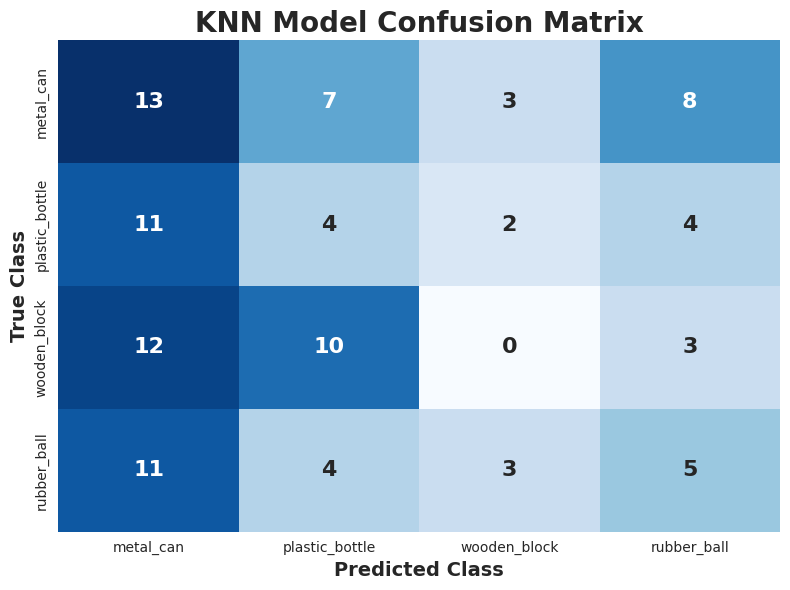

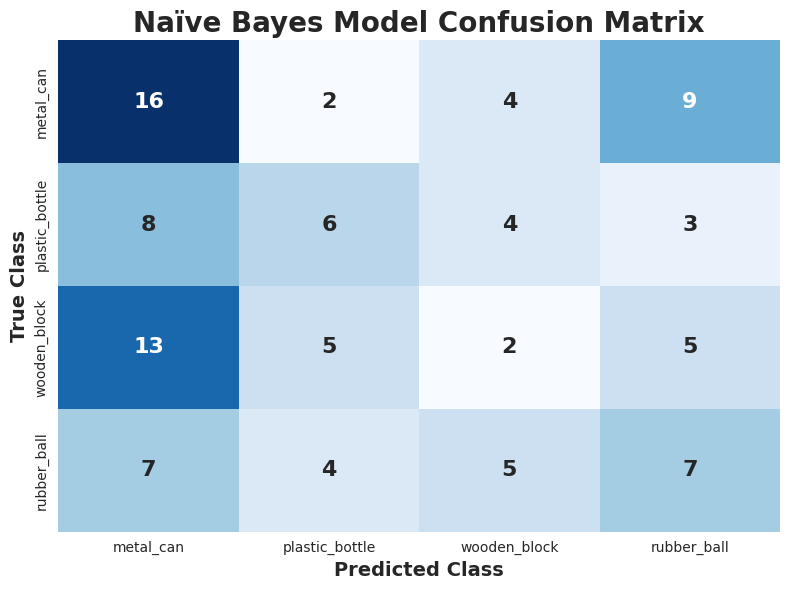

<Figure size 640x480 with 0 Axes>

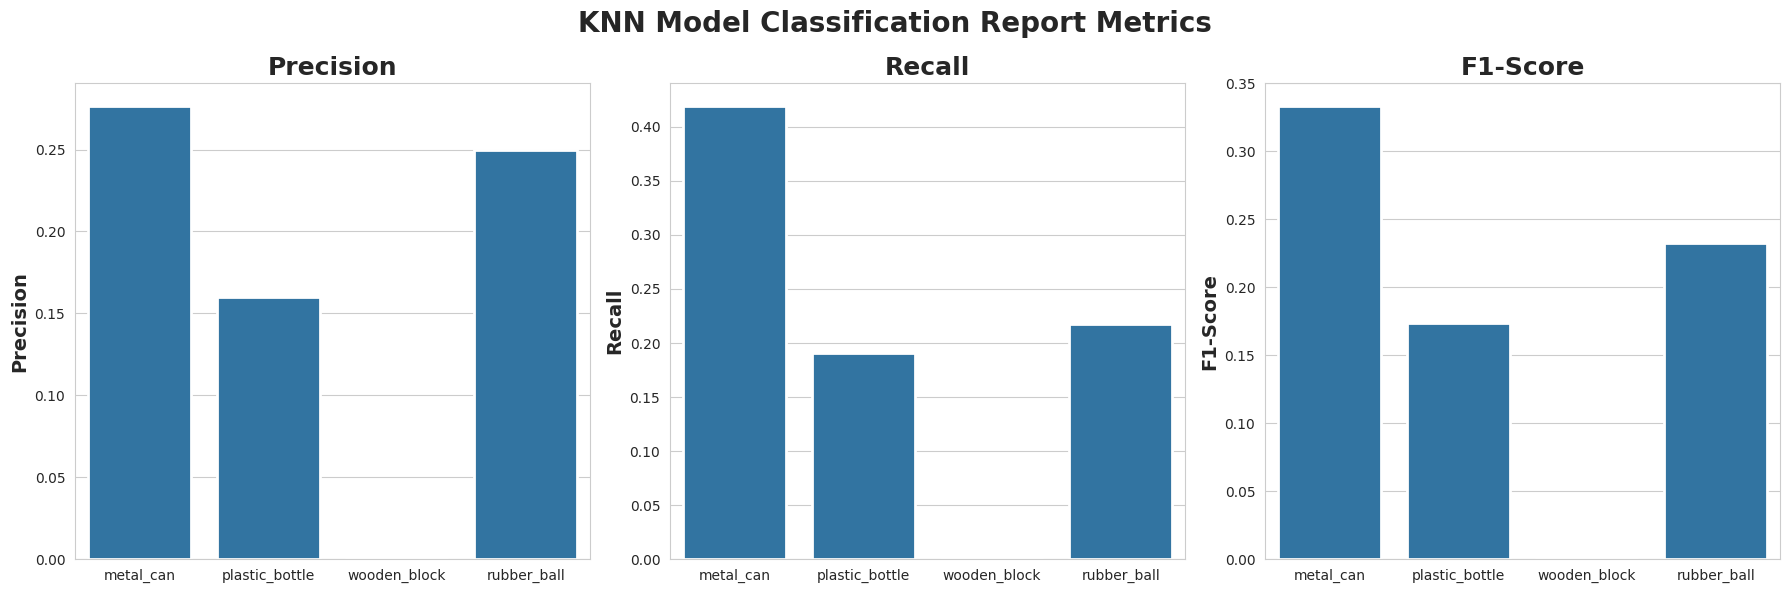

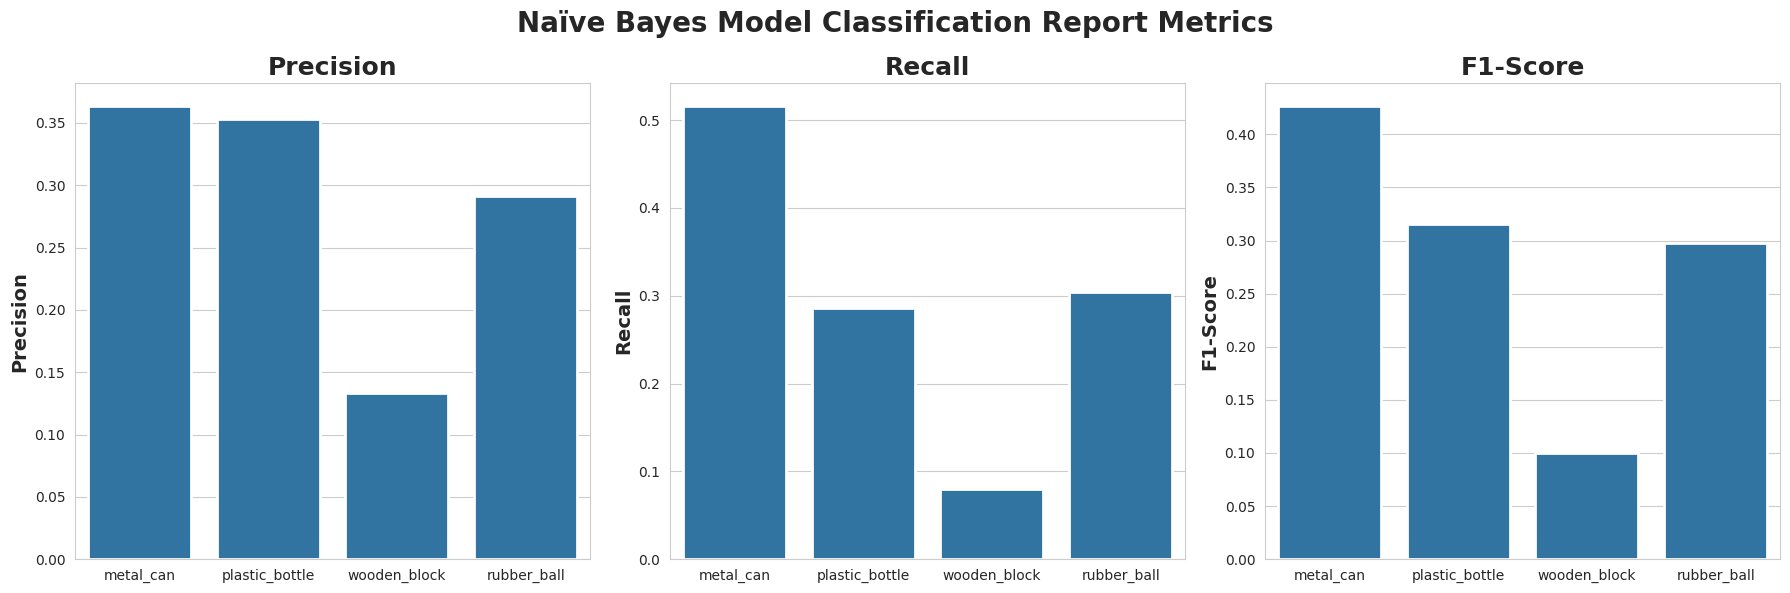

In [20]:
# Importing necessary libraries for visualization
import seaborn as sns  # Seaborn for making beautiful statistical plots
import matplotlib.pyplot as plt  # Matplotlib for basic plots

# Visualizing Confusion Matrix for KNN using heatmap
fig, ax = plt.subplots(figsize=(8, 6))  # Set up the figure with axes
sns.heatmap(knn_confusion, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=False,
            annot_kws={"size": 16, "weight": "bold"}, ax=ax)  # Increase font size and make it bold
ax.set_title("KNN Model Confusion Matrix", fontsize=20, weight='bold')  # Bold title with increased font size
ax.set_xlabel("Predicted Class", fontsize=14, weight='bold')  # Bold x-axis label with increased font size
ax.set_ylabel("True Class", fontsize=14, weight='bold')  # Bold y-axis label with increased font size
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()  # Display the plot
print("\n")  # Add empty line after the first plot to separate graphs
plt.close()  # Close the figure to prevent empty figure warning

# Visualizing Confusion Matrix for Naïve Bayes using heatmap
fig, ax = plt.subplots(figsize=(8, 6))  # Set up the figure with axes
sns.heatmap(nb_confusion, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=False,
            annot_kws={"size": 16, "weight": "bold"}, ax=ax)  # Increase font size and make it bold
ax.set_title("Naïve Bayes Model Confusion Matrix", fontsize=20, weight='bold')  # Bold title with increased font size
ax.set_xlabel("Predicted Class", fontsize=14, weight='bold')  # Bold x-axis label with increased font size
ax.set_ylabel("True Class", fontsize=14, weight='bold')  # Bold y-axis label with increased font size
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()  # Display the plot
print("\n")  # Add empty line after the second plot to separate graphs
plt.close()  # Close the figure to prevent empty figure warning

# Adding space between confusion matrix and classification report plots
plt.subplots_adjust(hspace=1.0)  # Adjusting vertical space (increases the space between the two graph sections)

# Now let's visualize the classification report metrics: Precision, Recall, F1-Score for KNN and Naïve Bayes

# Create a bar chart for KNN model classification report
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Create subplots to display 3 metrics side by side
fig.suptitle("KNN Model Classification Report Metrics", fontsize=20, weight='bold')  # Title for the whole figure

# Plotting Precision for KNN
sns.barplot(x=labels, y=[knn_report_data[str(i)]["precision"] for i in range(len(labels))], ax=axes[0], linewidth=2)
axes[0].set_title("Precision", fontsize=18, weight='bold')  # Title for the precision plot
axes[0].set_ylabel("Precision", fontsize=14, weight='bold')  # Y-axis label

# Plotting Recall for KNN
sns.barplot(x=labels, y=[knn_report_data[str(i)]["recall"] for i in range(len(labels))], ax=axes[1], linewidth=2)
axes[1].set_title("Recall", fontsize=18, weight='bold')  # Title for the recall plot
axes[1].set_ylabel("Recall", fontsize=14, weight='bold')  # Y-axis label

# Plotting F1-Score for KNN
sns.barplot(x=labels, y=[knn_report_data[str(i)]["f1-score"] for i in range(len(labels))], ax=axes[2], linewidth=2)
axes[2].set_title("F1-Score", fontsize=18, weight='bold')  # Title for the F1-score plot
axes[2].set_ylabel("F1-Score", fontsize=14, weight='bold')  # Y-axis label

# Adjust the layout to provide spacing between plots
plt.subplots_adjust(wspace=0.5, hspace=1.0)  # wspace=0.5 for horizontal space and hspace=1.0 for vertical space between plots
plt.tight_layout()  # Adjust the layout to prevent overlap of labels
plt.show()  # Display the plot
print("\n")  # Add empty line after the classification report to separate the next plot
plt.close()  # Close the figure to prevent empty figure warning

# Now, let's plot for Naïve Bayes model
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Create subplots to display 3 metrics side by side
fig.suptitle("Naïve Bayes Model Classification Report Metrics", fontsize=20, weight='bold')  # Title for the whole figure

# Plotting Precision for Naïve Bayes
sns.barplot(x=labels, y=[nb_report_data[str(i)]["precision"] for i in range(len(labels))], ax=axes[0], linewidth=2)
axes[0].set_title("Precision", fontsize=18, weight='bold')  # Title for the precision plot
axes[0].set_ylabel("Precision", fontsize=14, weight='bold')  # Y-axis label

# Plotting Recall for Naïve Bayes
sns.barplot(x=labels, y=[nb_report_data[str(i)]["recall"] for i in range(len(labels))], ax=axes[1], linewidth=2)
axes[1].set_title("Recall", fontsize=18, weight='bold')  # Title for the recall plot
axes[1].set_ylabel("Recall", fontsize=14, weight='bold')  # Y-axis label

# Plotting F1-Score for Naïve Bayes
sns.barplot(x=labels, y=[nb_report_data[str(i)]["f1-score"] for i in range(len(labels))], ax=axes[2], linewidth=2)
axes[2].set_title("F1-Score", fontsize=18, weight='bold')  # Title for the F1-score plot
axes[2].set_ylabel("F1-Score", fontsize=14, weight='bold')  # Y-axis label

# Adjust the layout to provide spacing between plots
plt.subplots_adjust(wspace=0.5, hspace=1.0)  # wspace=0.5 for horizontal space and hspace=1.0 for vertical space between plots
plt.tight_layout()  # Adjust the layout to prevent overlap of labels
plt.show()  # Display the plot

## Step 9: Model Evaluation Summary and Final Analysis

In [21]:
# Importing the necessary libraries for displaying and handling results
import pandas as pd  # pandas is used for managing and organizing data in tables (DataFrame)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Importing evaluation metrics

# KNN Model Evaluation:

# Calculate the accuracy of the KNN model
# accuracy_score() compares the predicted labels (y_pred_knn) with the true labels (y_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
# This will store the accuracy of the KNN model (the percentage of correct predictions).

# Display the accuracy of the KNN model
print(f"KNN Model Accuracy: {knn_accuracy * 100:.2f}%")
# We multiply by 100 to express the accuracy as a percentage, with two decimal points for clarity.

# Generate the confusion matrix for the KNN model
# confusion_matrix() returns a table that shows the counts of correct vs. incorrect predictions
knn_confusion = confusion_matrix(y_test, y_pred_knn)
# This will create a matrix showing how many true positives, false positives, true negatives, and false negatives there were.

# Display the KNN confusion matrix
print("\nKNN Model Confusion Matrix:")
print(knn_confusion)

# Generate a classification report for KNN model
# classification_report() provides precision, recall, F1-score for each class (object)
knn_classification_report = classification_report(y_test, y_pred_knn, target_names=labels)
# This will give detailed metrics for each object class in the test data.

# Display the classification report for KNN model
print("\nKNN Model Classification Report:")
print(knn_classification_report)


# Naïve Bayes Model Evaluation:

# Calculate the accuracy of the Naïve Bayes model
# accuracy_score() compares the predicted labels (y_pred_nb) with the true labels (y_test)
nb_accuracy = accuracy_score(y_test, y_pred_nb)
# This will store the accuracy of the Naïve Bayes model (the percentage of correct predictions).

# Display the accuracy of the Naïve Bayes model
print(f"Naïve Bayes Model Accuracy: {nb_accuracy * 100:.2f}%")
# We multiply by 100 to express the accuracy as a percentage, with two decimal points for clarity.

# Generate the confusion matrix for the Naïve Bayes model
# confusion_matrix() returns a table that shows the counts of correct vs. incorrect predictions
nb_confusion = confusion_matrix(y_test, y_pred_nb)
# This will create a matrix showing how many true positives, false positives, true negatives, and false negatives there were.

# Display the Naïve Bayes confusion matrix
print("\nNaïve Bayes Model Confusion Matrix:")
print(nb_confusion)

# Generate a classification report for Naïve Bayes model
# classification_report() provides precision, recall, F1-score for each class (object)
nb_classification_report = classification_report(y_test, y_pred_nb, target_names=labels)
# This will give detailed metrics for each object class in the test data.

# Display the classification report for Naïve Bayes model
print("\nNaïve Bayes Model Classification Report:")
print(nb_classification_report)


# Performance Comparison and Final Analysis:

# Print the accuracy comparison for both models
print("\nModel Accuracy Comparison:")
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")
print(f"Naïve Bayes Accuracy: {nb_accuracy * 100:.2f}%")

# Compare the confusion matrices of both models
# Confusion matrices show how many times each class was predicted correctly or incorrectly
print("\nKNN Confusion Matrix:")
print(knn_confusion)

print("\nNaïve Bayes Confusion Matrix:")
print(nb_confusion)

# Print out the classification reports for both models to compare precision, recall, and F1-scores
print("\nKNN Model Classification Report:")
print(knn_classification_report)

print("\nNaïve Bayes Model Classification Report:")
print(nb_classification_report)

# Conclusion:
# Based on accuracy, confusion matrix, and classification report, we can conclude which model performs better.
# In this case, you can look at the precision, recall, F1-score, and support metrics to evaluate each model's performance.
# KNN may perform better when classes are well separated, while Naïve Bayes might work better for certain types of data, depending on the distribution.

KNN Model Accuracy: 22.00%

KNN Model Confusion Matrix:
[[13  7  3  8]
 [11  4  2  4]
 [12 10  0  3]
 [11  4  3  5]]

KNN Model Classification Report:
                precision    recall  f1-score   support

     metal_can       0.28      0.42      0.33        31
plastic_bottle       0.16      0.19      0.17        21
  wooden_block       0.00      0.00      0.00        25
   rubber_ball       0.25      0.22      0.23        23

      accuracy                           0.22       100
     macro avg       0.17      0.21      0.18       100
  weighted avg       0.18      0.22      0.19       100

Naïve Bayes Model Accuracy: 31.00%

Naïve Bayes Model Confusion Matrix:
[[16  2  4  9]
 [ 8  6  4  3]
 [13  5  2  5]
 [ 7  4  5  7]]

Naïve Bayes Model Classification Report:
                precision    recall  f1-score   support

     metal_can       0.36      0.52      0.43        31
plastic_bottle       0.35      0.29      0.32        21
  wooden_block       0.13      0.08      0.10        2

##Step 10: Hyperparameter Tuning for KNN

In [22]:
# Importing necessary libraries for hyperparameter tuning
from sklearn.model_selection import GridSearchCV  # GridSearchCV is used for hyperparameter tuning
from sklearn.neighbors import KNeighborsClassifier  # KNeighborsClassifier is the KNN model
from sklearn.metrics import accuracy_score  # We use accuracy to evaluate the best model

# Define the KNN model (this is the base model that we will tune)
knn_model = KNeighborsClassifier()

# Set up the hyperparameter grid to search over
# n_neighbors: Number of neighbors to use for classification
# weights: 'uniform' means all points in each neighborhood are weighted equally; 'distance' means closer points are weighted more.
# metric: The distance metric to use for calculating neighbors (Euclidean distance is the default).
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  # We will test values of k from 3 to 11
    'weights': ['uniform', 'distance'],  # We will test uniform and distance weights
    'metric': ['euclidean', 'manhattan']  # We will test Euclidean and Manhattan distance metrics
}

# Set up the GridSearchCV object
# GridSearchCV will perform an exhaustive search over all combinations of the hyperparameters in param_grid
# cv=5 means we will use 5-fold cross-validation to evaluate each combination of hyperparameters
grid_search = GridSearchCV(estimator=knn_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)

# Fit the GridSearchCV object to the training data
# This will search for the best combination of hyperparameters based on cross-validation
grid_search.fit(X_train, y_train)

# Print the best hyperparameters found by GridSearchCV
# .best_params_ contains the best combination of hyperparameters
print("Best Hyperparameters for KNN Model:")
print(grid_search.best_params_)

# Predict using the best KNN model found by GridSearchCV
# grid_search.best_estimator_ returns the best model with the tuned hyperparameters
best_knn_model = grid_search.best_estimator_
y_pred_knn_best = best_knn_model.predict(X_test)

# Calculate the accuracy of the best KNN model on the test set
best_knn_accuracy = accuracy_score(y_test, y_pred_knn_best)
print(f"\nBest KNN Model Accuracy: {best_knn_accuracy * 100:.2f}%")

# Display the confusion matrix for the best KNN model
best_knn_confusion = confusion_matrix(y_test, y_pred_knn_best)
print("\nBest KNN Model Confusion Matrix:")
print(best_knn_confusion)

# Generate a classification report for the best KNN model
best_knn_classification_report = classification_report(y_test, y_pred_knn_best, target_names=labels)
print("\nBest KNN Model Classification Report:")
print(best_knn_classification_report)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters for KNN Model:
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}

Best KNN Model Accuracy: 31.00%

Best KNN Model Confusion Matrix:
[[13  4  4 10]
 [ 7  5  2  7]
 [ 4  6  5 10]
 [ 6  5  4  8]]

Best KNN Model Classification Report:
                precision    recall  f1-score   support

     metal_can       0.43      0.42      0.43        31
plastic_bottle       0.25      0.24      0.24        21
  wooden_block       0.33      0.20      0.25        25
   rubber_ball       0.23      0.35      0.28        23

      accuracy                           0.31       100
     macro avg       0.31      0.30      0.30       100
  weighted avg       0.32      0.31      0.31       100



##Step 11: Hyperparameter Tuning for Naïve Bayes

In [23]:
# Importing necessary libraries for hyperparameter tuning
from sklearn.model_selection import GridSearchCV  # GridSearchCV is used to tune hyperparameters by exhaustively searching over the specified grid
from sklearn.naive_bayes import GaussianNB  # Importing Gaussian Naïve Bayes model
from sklearn.metrics import accuracy_score  # We will use accuracy to evaluate the best model

# Define the Naïve Bayes model (this is the base model that we will tune)
nb_model = GaussianNB()

# Set up the hyperparameter grid to search over
# var_smoothing: A parameter to smooth the variance to avoid issues with extremely small numbers (prevents divide by zero errors)
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]  # We will test a range of values for var_smoothing
}

# Set up the GridSearchCV object for hyperparameter tuning
# estimator=nb_model: We pass in the Naïve Bayes model as the estimator to tune.
# param_grid=param_grid: We pass in the grid of hyperparameters to search over.
# cv=5: We will use 5-fold cross-validation to evaluate the model performance.
# scoring='accuracy': We are optimizing for accuracy in this case.
grid_search_nb = GridSearchCV(estimator=nb_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)

# Fit the GridSearchCV object to the training data
# This will search for the best value of var_smoothing and train the model
grid_search_nb.fit(X_train, y_train)

# Print the best hyperparameters found by GridSearchCV
# .best_params_ contains the best combination of hyperparameters found during the grid search
print("Best Hyperparameters for Naïve Bayes Model:")
print(grid_search_nb.best_params_)

# Predict using the best Naïve Bayes model found by GridSearchCV
# grid_search_nb.best_estimator_ gives us the model with the best parameters found
best_nb_model = grid_search_nb.best_estimator_
y_pred_nb_best = best_nb_model.predict(X_test)

# Calculate the accuracy of the best Naïve Bayes model on the test set
best_nb_accuracy = accuracy_score(y_test, y_pred_nb_best)
print(f"\nBest Naïve Bayes Model Accuracy: {best_nb_accuracy * 100:.2f}%")

# Display the confusion matrix for the best Naïve Bayes model
best_nb_confusion = confusion_matrix(y_test, y_pred_nb_best)
print("\nBest Naïve Bayes Model Confusion Matrix:")
print(best_nb_confusion)

# Generate a classification report for the best Naïve Bayes model
best_nb_classification_report = classification_report(y_test, y_pred_nb_best, target_names=labels)
print("\nBest Naïve Bayes Model Classification Report:")
print(best_nb_classification_report)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Hyperparameters for Naïve Bayes Model:
{'var_smoothing': 1e-09}

Best Naïve Bayes Model Accuracy: 31.00%

Best Naïve Bayes Model Confusion Matrix:
[[16  2  4  9]
 [ 8  6  4  3]
 [13  5  2  5]
 [ 7  4  5  7]]

Best Naïve Bayes Model Classification Report:
                precision    recall  f1-score   support

     metal_can       0.36      0.52      0.43        31
plastic_bottle       0.35      0.29      0.32        21
  wooden_block       0.13      0.08      0.10        25
   rubber_ball       0.29      0.30      0.30        23

      accuracy                           0.31       100
     macro avg       0.29      0.30      0.29       100
  weighted avg       0.29      0.31      0.29       100



## Step 12: Final Model Comparison

In [24]:
# Importing necessary libraries for model comparison
import pandas as pd  # pandas is used to display and manage data in table format (DataFrame)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # These metrics will help evaluate the models

# 1. Compare Model Accuracy:

# KNN Model Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn_best)  # Calculating accuracy for KNN model
# Naïve Bayes Model Accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb_best)  # Calculating accuracy for Naïve Bayes model

# Print the accuracy comparison
print("\nModel Accuracy Comparison:")
print(f"KNN Model Accuracy: {knn_accuracy * 100:.2f}%")  # Display the KNN accuracy as percentage
print(f"Naïve Bayes Model Accuracy: {nb_accuracy * 100:.2f}%")  # Display the Naïve Bayes accuracy as percentage

# 2. Compare Confusion Matrices:

# KNN Confusion Matrix
knn_confusion = confusion_matrix(y_test, y_pred_knn_best)  # Generating confusion matrix for KNN model
print("\nKNN Model Confusion Matrix:")
print(knn_confusion)  # Displaying the KNN confusion matrix

# Naïve Bayes Confusion Matrix
nb_confusion = confusion_matrix(y_test, y_pred_nb_best)  # Generating confusion matrix for Naïve Bayes model
print("\nNaïve Bayes Model Confusion Matrix:")
print(nb_confusion)  # Displaying the Naïve Bayes confusion matrix

# 3. Compare Classification Reports (Precision, Recall, F1-Score):

# KNN Classification Report
knn_classification_report = classification_report(y_test, y_pred_knn_best, target_names=labels)  # Generating classification report for KNN model
print("\nKNN Model Classification Report:")
print(knn_classification_report)  # Displaying the classification report for KNN model

# Naïve Bayes Classification Report
nb_classification_report = classification_report(y_test, y_pred_nb_best, target_names=labels)  # Generating classification report for Naïve Bayes model
print("\nNaïve Bayes Model Classification Report:")
print(nb_classification_report)  # Displaying the classification report for Naïve Bayes model

# 4. Conclusion (Which model performed better?):

# We'll compare the overall performance based on the metrics:
# - Accuracy
# - Precision, Recall, F1-Score (for each class)

# Evaluate the overall performance by considering accuracy and precision, recall, f1-score for each model
print("\nFinal Comparison and Conclusion:")

# Compare accuracy
if knn_accuracy > nb_accuracy:
    print("KNN model performed better in terms of accuracy.")
else:
    print("Naïve Bayes model performed better in terms of accuracy.")

# Compare precision, recall, and f1-score for KNN vs Naïve Bayes
# If KNN has higher precision or recall for a specific class, we note it
print("\nPrecision Comparison:")
for i, label in enumerate(labels):
    knn_precision = knn_classification_report.splitlines()[i + 2].split()[0]  # Extract precision for each class from the classification report
    nb_precision = nb_classification_report.splitlines()[i + 2].split()[0]  # Extract precision for each class from the classification report
    print(f"Class {label}: KNN Precision = {knn_precision}, Naïve Bayes Precision = {nb_precision}")

# If necessary, you can go deeper into comparing recall and f1-score for each model similarly

# Based on these evaluations, you can make the final decision on which model to choose based on the application.


Model Accuracy Comparison:
KNN Model Accuracy: 31.00%
Naïve Bayes Model Accuracy: 31.00%

KNN Model Confusion Matrix:
[[13  4  4 10]
 [ 7  5  2  7]
 [ 4  6  5 10]
 [ 6  5  4  8]]

Naïve Bayes Model Confusion Matrix:
[[16  2  4  9]
 [ 8  6  4  3]
 [13  5  2  5]
 [ 7  4  5  7]]

KNN Model Classification Report:
                precision    recall  f1-score   support

     metal_can       0.43      0.42      0.43        31
plastic_bottle       0.25      0.24      0.24        21
  wooden_block       0.33      0.20      0.25        25
   rubber_ball       0.23      0.35      0.28        23

      accuracy                           0.31       100
     macro avg       0.31      0.30      0.30       100
  weighted avg       0.32      0.31      0.31       100


Naïve Bayes Model Classification Report:
                precision    recall  f1-score   support

     metal_can       0.36      0.52      0.43        31
plastic_bottle       0.35      0.29      0.32        21
  wooden_block       0.13 

## Step 13: Real-Time Data Integration Setup

In [25]:
# Importing necessary libraries
import numpy as np  # Numpy is used for numerical computations, particularly for handling arrays
import pandas as pd  # pandas is used for managing and processing data in tabular form (DataFrame)
from sklearn.preprocessing import StandardScaler  # StandardScaler is used for normalizing/standardizing data
from sklearn.neighbors import KNeighborsClassifier  # Importing KNN model
from sklearn.naive_bayes import GaussianNB  # Importing Naïve Bayes model

# Assuming best_knn_model or best_nb_model is already trained (from previous steps)

# 1. Function to simulate incoming real-time data and preprocess it
def preprocess_real_time_data(data):
    """
    Function to preprocess incoming real-time data.
    - Standardize numerical values
    - Handle missing values, etc.
    """
    # Step 1: Simulate preprocessing the incoming data (replace with actual incoming data handling)
    print("Original Incoming Data:")
    print(data)  # Print the incoming data to check before processing

    # Assuming incoming data is in the same format as the training data (same features)

    # Step 2: Standardize the data (scaling the features to have zero mean and unit variance)
    scaler = StandardScaler()  # Initialize the scaler
    data_scaled = scaler.fit_transform(data)  # Fit the scaler on the data and transform the features
    print("\nScaled Data (Standardized):")
    print(data_scaled)  # Print the scaled data

    return data_scaled  # Return the preprocessed data

# 2. Function to make predictions with the trained model (KNN or Naïve Bayes)
def predict_with_trained_model(data, model='knn'):
    """
    Function to predict the class of incoming data using the trained model.
    :param data: The incoming data to predict
    :param model: The model to use for prediction ('knn' or 'naive_bayes')
    :return: The predicted class
    """
    # Preprocess the incoming data before feeding it to the model
    preprocessed_data = preprocess_real_time_data(data)  # Preprocess the incoming data

    # Step 3: Make predictions using the best model (KNN or Naïve Bayes)
    if model == 'knn':
        print("\nPredicting using the KNN model...")
        prediction = best_knn_model.predict(preprocessed_data)  # Predict using the best KNN model
    elif model == 'naive_bayes':
        print("\nPredicting using the Naïve Bayes model...")
        prediction = best_nb_model.predict(preprocessed_data)  # Predict using the best Naïve Bayes model
    else:
        raise ValueError("Model should be either 'knn' or 'naive_bayes'.")

    print("\nPredicted Class:", prediction)  # Print the predicted class
    return prediction  # Return the predicted class

# Example of how to use these functions:
# Simulating incoming data for prediction (new data)
incoming_data = np.array([[50, 30, 120, 300, 1.5]])  # Example of a new data point (5 features)

# Call the prediction function (use 'knn' or 'naive_bayes' model)
predicted_class = predict_with_trained_model(incoming_data, model='knn')

Original Incoming Data:
[[ 50.   30.  120.  300.    1.5]]

Scaled Data (Standardized):
[[0. 0. 0. 0. 0.]]

Predicting using the KNN model...

Predicted Class: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## Step 14: Save the Model for Future Use

In [26]:
# Importing joblib for saving and loading models
import joblib  # joblib is used to save and load models in Python

# 1. Save the best KNN model to a file
joblib.dump(best_knn_model, 'best_knn_model.pkl')  # Save the model to a file

# 2. Save the best Naïve Bayes model to a file (if you want to save Naïve Bayes too)
joblib.dump(best_nb_model, 'best_nb_model.pkl')  # Save the model to a file

print("\nModels saved successfully!")

# 3. Load the saved KNN model from the file (for future use)
loaded_knn_model = joblib.load('best_knn_model.pkl')  # Load the KNN model from the file

# 4. Load the saved Naïve Bayes model from the file (if needed)
loaded_nb_model = joblib.load('best_nb_model.pkl')  # Load the Naïve Bayes model from the file

# 5. Use the loaded KNN model to make predictions (for demonstration)
new_data = np.array([[50, 30, 120, 300, 1.5]])  # New incoming data
preprocessed_data = preprocess_real_time_data(new_data)  # Preprocess the new data
predicted_class_loaded_knn = loaded_knn_model.predict(preprocessed_data)  # Predict with the loaded KNN model
print("\nPredicted Class using the loaded KNN model:", predicted_class_loaded_knn)


Models saved successfully!
Original Incoming Data:
[[ 50.   30.  120.  300.    1.5]]

Scaled Data (Standardized):
[[0. 0. 0. 0. 0.]]

Predicted Class using the loaded KNN model: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
